# Sound Morphing in Descript Audio Codec

In [1]:
%pwd

[Errno 2] No such file or directory: 'pwd'
/home/mille/dac_test


## Imports

In [2]:
from pathlib import Path

import torch
import torchaudio
from IPython.display import Audio
import dac
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

In [3]:
#@title Download and load DAC model

model_path = dac.utils.download()
model = dac.DAC.load(model_path)
model = model.to('cpu')

/home/mille/miniconda3/envs/dac/lib/python3.13/site-packages/torch/nn/utils/weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


In [4]:
output_dir = "output"

In [ ]:
# you cannot encode waveforms frame by frame due to the nature of the cnn
test_waveform = torch.rand(1, 320, device="cpu")
test_embed = model.encode(test_waveform.unsqueeze(0))[0]

We will start by loading in two audio signals. ```beatbox_aligned.wav``` is a beatbox recording that mimics the groove of ```TS_PR_110_drums_upbeat_hat_opening.wav```. Both recordings have been warped using NewTime to align with the same 16th note grid. This should ensure that interpolating between each drum sound will create a sort of drum/beatbox hybrid sound.

In [5]:
file_1 = "beatbox_aligned.wav"
file_2 = "TS_PR_110_drums_upbeat_hat_opening.wav"

In [8]:
# Load the audio file

def load_mono(file_name, target_sr):
    audio, sr = torchaudio.load(file_name)
    if audio.shape[0] > 1:
        audio = audio.mean(0, keepdim=True)

    if sr != target_sr:
        audio = torchaudio.functional.resample(audio, sr, target_sr)
        sr = target_sr
    audio = audio.clamp(-1, 1)
    return audio

target_sr = model.sample_rate  # Target sample rate to match the model's requirements
audio_1 = load_mono(file_1, target_sr)
audio_2 = load_mono(file_2, target_sr)


# Show the excerpt
display(Audio(audio_1, rate=target_sr))
display(Audio(audio_2, rate=target_sr))

The encoder is essentially a neural network consisting of many layers of multi-channel convolution. Each layer has a set number of channels, each characterized by a kernel of a set length. The kernel lengths are trained, in a similar fashion to conventional neural networks, to minimize some optimization function. After each convolutional layer, the multi-channel output is added together into a weighted mean (the weights of which are also trained), which is then used as input for the next convolutional layer. The embedded output of the encoder is the multi-channel output of the final convolutional layer, where each channel corresponds to a variable, or dimension in the embedding space, and each time-step corresponds to a "frame" in the full-length audio signal.

Below you can see the 64 channel-characterizing kernels for the first convolutional layer in the encoder.

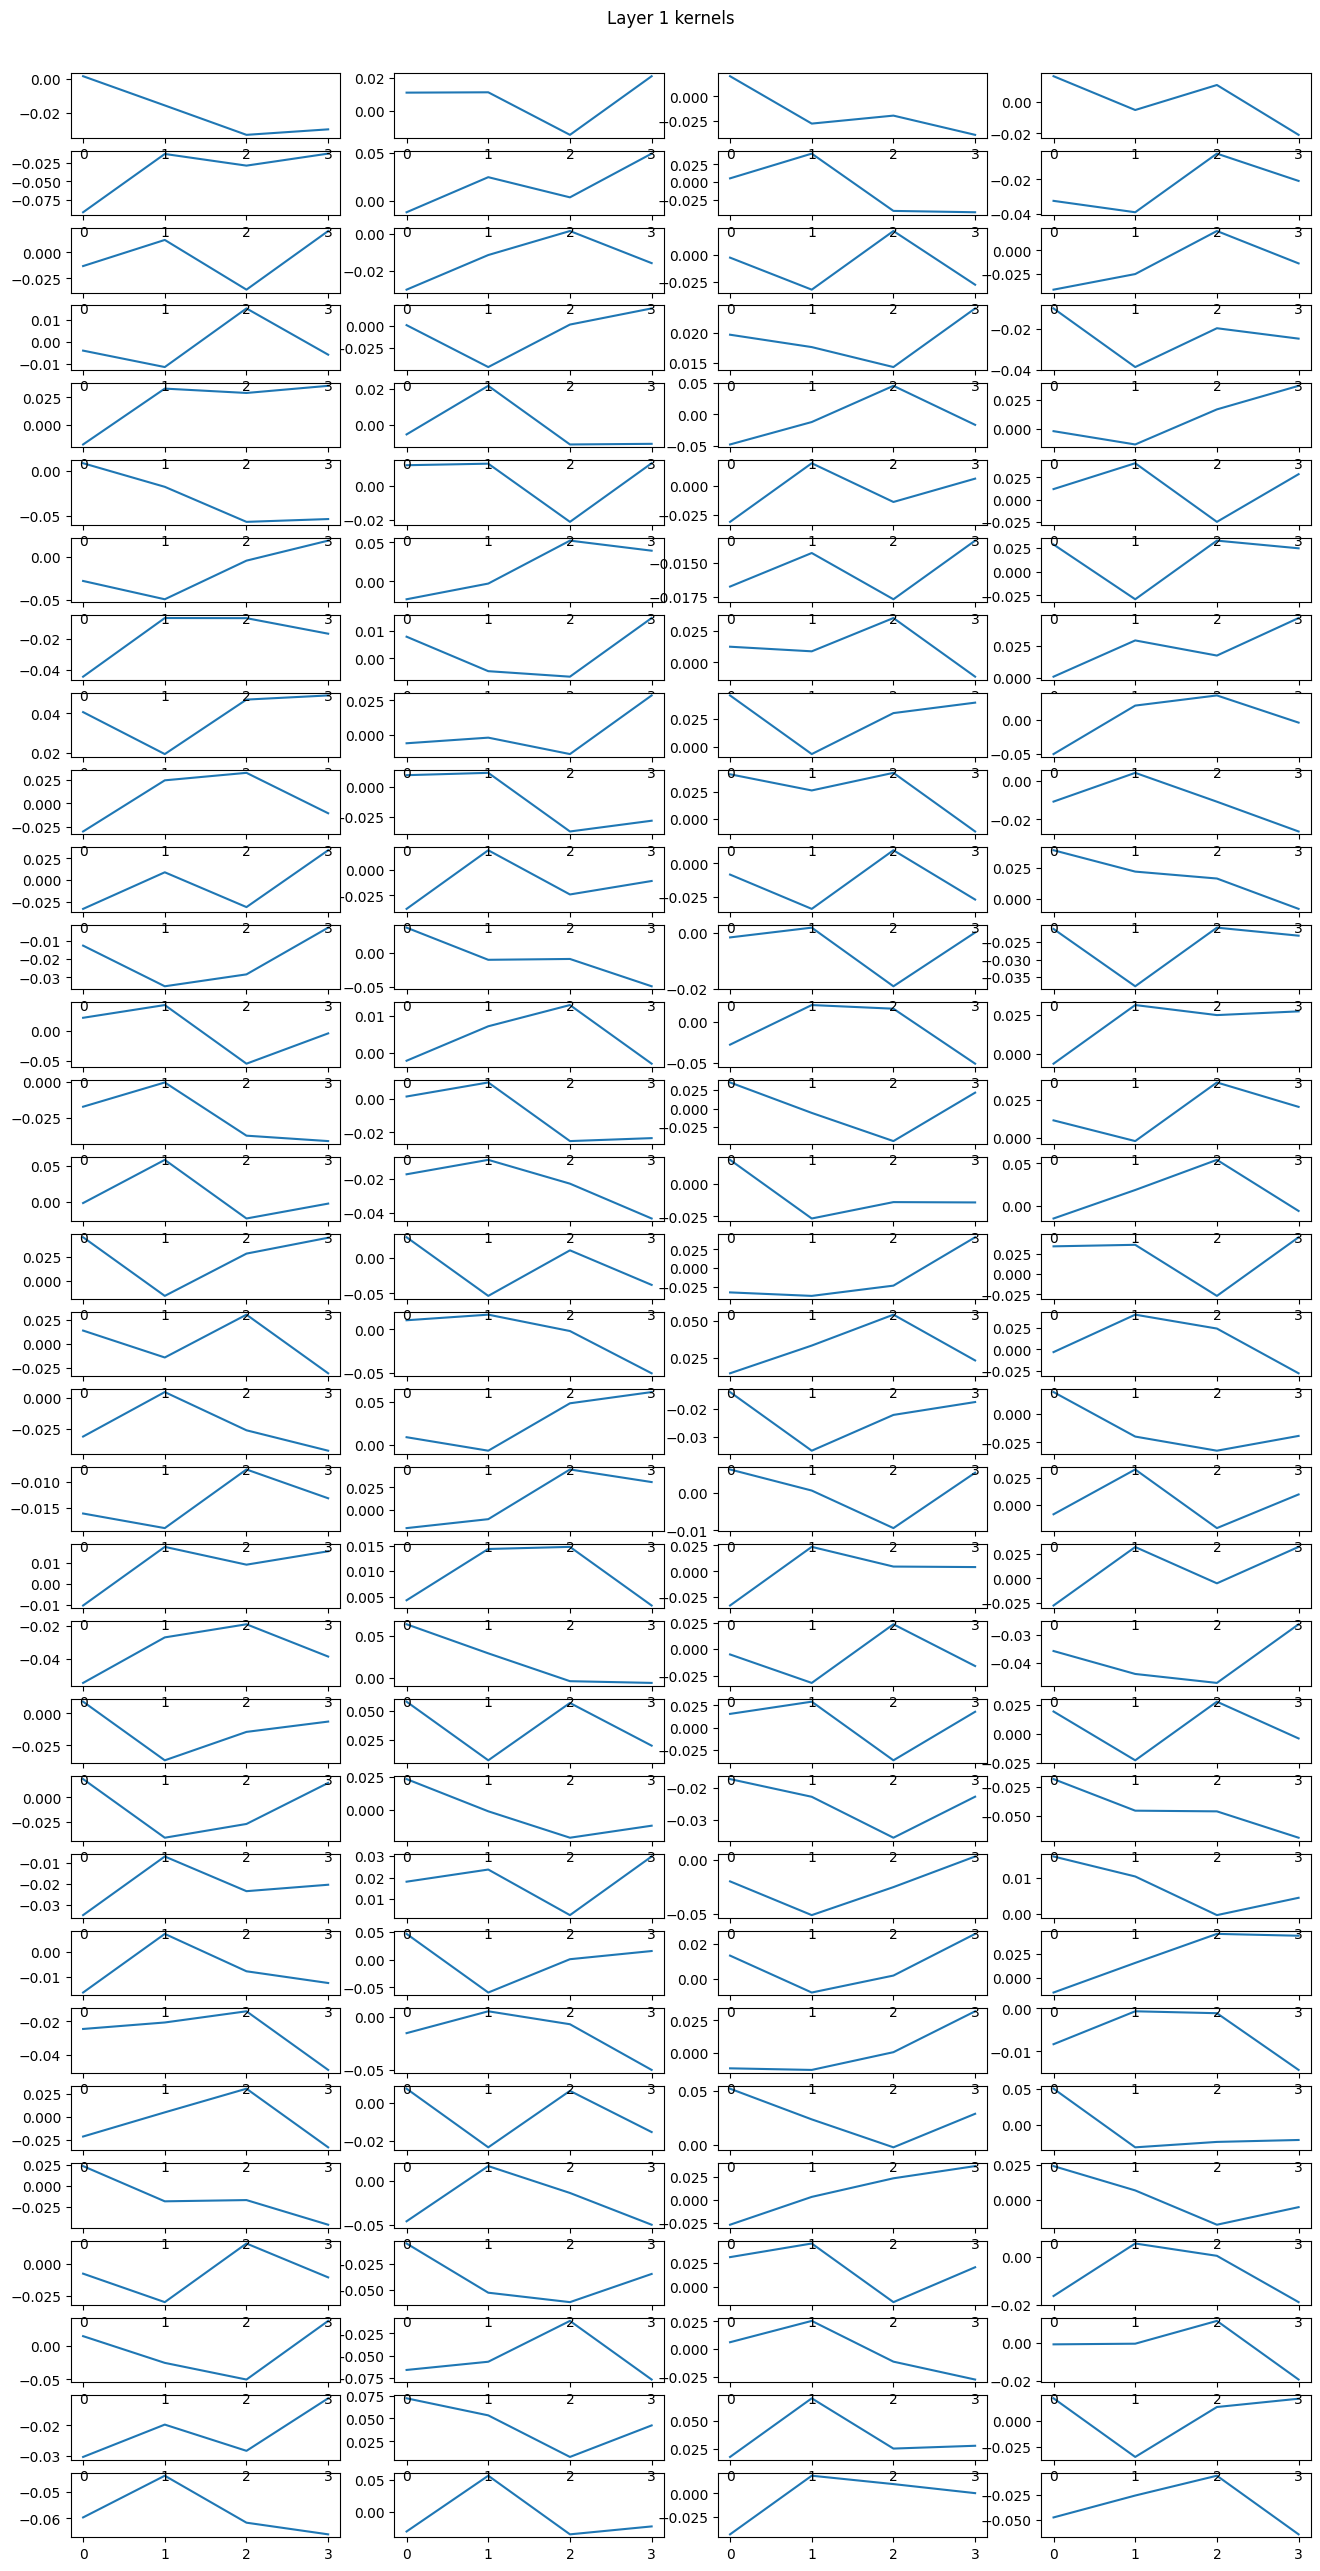

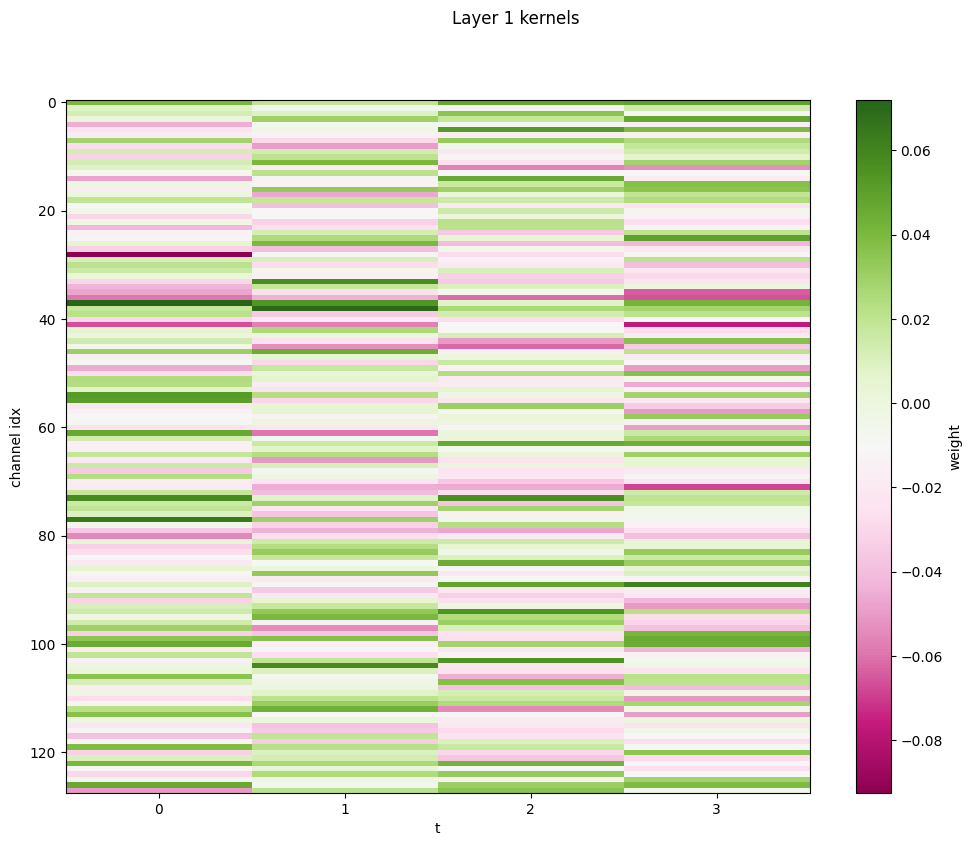

In [ ]:
# layer 1 convolution kernels
def plot_kernels(kernels, suptitle=None):
    n_columns = 4
    n_rows = np.shape(kernels)[0]//4

    fig = plt.figure(figsize=(16, 32))
    gs = gridspec.GridSpec(n_rows, n_columns)

    for i, kernel in enumerate(kernels):
        ax = plt.subplot(gs[(n_rows-i)//4, i%4])
        ax.plot(kernel[0])

    fig.suptitle(suptitle, y=0.9)

    plt.figure(figsize=(12, 9))
    im = plt.imshow(kernels[:,0,:], aspect="auto", cmap="PiYG")
    plt.colorbar(label="weight")
    plt.xticks(np.arange(0,np.shape(kernels)[2]))
    plt.xlabel("t")
    plt.ylabel("channel idx")
    plt.suptitle(suptitle)

# kernels = model.encoder.block[0].weight.detach().cpu().numpy() # Layer 1 kernels
# plot_kernels(kernels, "Layer 1 kernels")

# kernels = model.encoder.block[1].block[4].weight.detach().cpu().numpy() # Layer 2 Residual Unit 1 Stride kernels
# plot_kernels(kernels, "Layer 2 Residual Unit 1 Stride kernels")

kernels = model.encoder.block[1].block[4].weight.detach().cpu().numpy() # Layer 2 Residual Unit 1 Stride kernels
plot_kernels(kernels, "Layer 2 Residual Unit 1 Stride kernels")


In [10]:
#@title Encode to unquantized embedding z
with torch.inference_mode():
    z1 = model.encoder(model.preprocess(audio_1, target_sr).to(model.device).unsqueeze(0))

The encoder embeds each interval (referred to as frame) of 320 time steps in the full-length signal into a point in a 1024-dimensional embedded space. Here is a signal-space representation of the first embedded frame of ```beatbox_aligned.wav```.

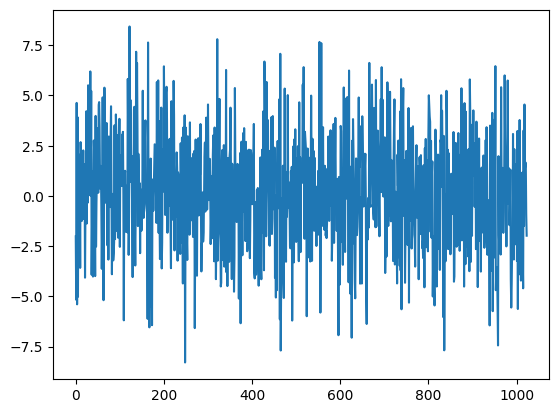

In [11]:
first_col = z1[0, :, 0]

plt.plot(first_col)

The embeddings are projected onto a lower-dimensional 8D *codebook space*, where they are mapped to one out of a set of primary codebook vectors. Each frame is mapped to the codebook vector which its codebook space representation is closest to with regards to L2 distance. A *quantized* representation of the original embedding can be retrived by re-projecting the selected codebook vector back onto the embedding space. The unquantized embedding is then subtracted by the quantized embedding, resulting in a *residual*, which is similarily quantized using a separate residual codebook space and vector set, creating another residual and so forth. This procedure is repeated until a primary quantization and eight residuals have been created. Quantization allows the embeddings to be stored as a set of 9 codebook indices rather than 1024 floating point values.

To reconstruct the audio signal, the primary and residuals for each frame are added together, and processed by the model's decoder.

In [12]:
# project into 1st latent/codebook space representation z_1e

# W_in, W_out are in this implementation "folded" into multi-channel convolutions. The weights are trained by training the kernels

residuals = [z1]
in_proj_matrices = []
latents = []
q_latents = []
out_proj_matrices = []
q_embeddings = []

residual = z1

for i, quantizer in enumerate(model.quantizer.quantizers):
    with torch.inference_mode():
        z_e_i = quantizer.in_proj(residual)
        in_proj_matrix = quantizer.in_proj.weight.detach().cpu().numpy()
        z_q_proj_i, _ = quantizer.decode_latents(z_e_i)
        z_q_i = quantizer.out_proj(z_q_proj_i)

        out_proj_matrix = quantizer.out_proj.weight.detach().cpu().numpy()

        in_proj_matrices.append(in_proj_matrix)
        latents.append(z_e_i)
        q_latents.append(z_q_proj_i)
        out_proj_matrices.append(out_proj_matrix)
        q_embeddings.append(z_q_i)

        residual = residual-z_q_i

        residuals.append(residual)

z_q = torch.zeros_like(z1)
for z_q_i in q_embeddings:
    z_q += z_q_i
# plt.plot(z1_1e[0,:,0])

# plt.figure(figsize=(12, 2))
# in_proj_kernels = model.quantizer.quantizers[0].in_proj.weight.detach().cpu().numpy()
# plt.imshow(in_proj_kernels[:,:,0], aspect="auto", cmap="PiYG")
# plt.colorbar(label="weight")

In [13]:
with torch.inference_mode():
    z1_1q = model.quantizer.quantizers[0].out_proj(z1_1e)

plt.plot(z1_1q[0,:,0])

plt.figure(figsize=(2, 12))
in_proj_kernels = model.quantizer.quantizers[0].out_proj.weight.detach().cpu().numpy()
plt.imshow(in_proj_kernels[:,:,0], aspect="auto", cmap="PiYG")
plt.colorbar(label="weight")

z1_res1 = z1-z1_1q

plt.figure()
plt.plot(z1_res1[0,:,0])

NameError: name 'z1_1e' is not defined

In [14]:
with torch.inference_mode():
    z2 = model.encoder(model.preprocess(audio_2, target_sr).to(model.device).unsqueeze(0))

In the embedded space, we can create a hybrid of the two input sounds by linearily interpolating between each pair of points. Since each embedded space vairable represents some sort of expressive property of the audio, interpolating between two points on an axis corresponds two modulating that property to some point in the middle. At how far along these interpolations we decide to "sample" our hybrid (```alpha```) will determine how much "weight" each sound will have in the output.

In [15]:
alpha = 0.5

# truncate length of combined signal to length of shortest signal
l = min(z_q.shape[2], z2.shape[2])
z_q = z_q[:,:,:l]; z2 = z2[:,:,:l]

z_morph = alpha * z_q + (1-alpha) * z2

with torch.inference_mode():
    z_morph_q, _, _, _, _ = model.quantizer(z_morph)
    audio_morph = model.decode(z_morph_q)

display(Audio(audio_morph[0].detach().cpu().numpy(), rate=target_sr))